# ✈️ Airline Customer Churn Prediction: A Data-Driven Approach

This notebook presents a comprehensive analysis of airline customer data to identify key factors contributing to churn and develop actionable strategies for retention. It encompasses data cleaning, exploratory data analysis, feature engineering, and churn labeling, culminating in a robust dataset ready for machine learning model development.

##  Business Problem

Customer churn is a critical challenge for airlines, directly impacting revenue and long-term profitability. Retaining existing customers is often more cost-effective than acquiring new ones. This project aims to:

1.  **Identify drivers of churn**: Understand what demographic, behavioral, and loyalty-related factors cause customers to leave.
2.  **Predict churn**: Develop a robust dataset that can be used to build a predictive model to identify customers at high risk of churning.
3.  **Inform retention strategies**: Provide data-driven insights and recommendations for targeted interventions to reduce churn and enhance customer loyalty.

## Setup and Data Loading

This section handles the initial environment setup, including mounting Google Drive for data access and loading the necessary datasets into pandas DataFrames. We are working with four distinct datasets:

*   `Airline Loyalty Data Dictionary.csv`: Provides metadata and descriptions for the other datasets.
*   `Customer Flight Activity.csv`: Contains detailed records of customer flight behavior.
*   `Customer Loyalty History.csv`: Stores historical information about customer loyalty programs.
*   `Calendar.csv`: Likely contains time-based information to support date-related analysis.

In [ ]:
#Basic imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


## Data Loading and Initial Exploration

This section loads the activity and loyalty datasets, cleans column names by stripping whitespace, and conducts initial data inspection to understand dimensions, data types, missing values, and duplicates.

In [ ]:
activity = pd.read_csv("Customer Flight Activity.csv")
loyalty  = pd.read_csv("Customer Loyalty History.csv")

In [ ]:
activity.columns = activity.columns.str.strip()
loyalty.columns  = loyalty.columns.str.strip()

In [ ]:
print(f"Activity shape: {activity.shape}")
print(f"Loyalty shape:  {loyalty.shape}")

Activity shape: (392936, 8)
Loyalty shape:  (16737, 16)


### Inspect Activity Data

First, let's check the shape and data types of both datasets to understand what we're working with.

In [ ]:
activity.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392936 entries, 0 to 392935
Data columns (total 8 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Loyalty Number               392936 non-null  int64  
 1   Year                         392936 non-null  int64  
 2   Month                        392936 non-null  int64  
 3   Total Flights                392936 non-null  int64  
 4   Distance                     392936 non-null  int64  
 5   Points Accumulated           392936 non-null  float64
 6   Points Redeemed              392936 non-null  int64  
 7   Dollar Cost Points Redeemed  392936 non-null  int64  
dtypes: float64(1), int64(7)
memory usage: 24.0 MB


In [ ]:
activity.isnull().sum()

,0
Loyalty Number,0
Year,0
Month,0
Total Flights,0
Distance,0
Points Accumulated,0
Points Redeemed,0
Dollar Cost Points Redeemed,0


In [ ]:
print(activity.duplicated().sum())

1922


In [ ]:
activity.drop_duplicates()

,Loyalty Number,Year,Month,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
0,100590,2018,6,12,15276,22914.0,0,0
1,100590,2018,7,12,9168,13752.0,0,0
2,100590,2018,5,4,6504,9756.0,0,0
3,100590,2018,10,0,0,0.0,512,92
4,100590,2018,2,0,0,0.0,0,0
...,...,...,...,...,...,...,...,...
392931,999986,2018,4,0,0,0.0,0,0
392932,999986,2018,5,0,0,0.0,0,0
392933,999986,2018,6,0,0,0.0,0,0
392934,999986,2018,9,0,0,0.0,0,0


In [ ]:
activity = activity.groupby(
    ['Loyalty Number', 'Year', 'Month'], as_index=False
).agg({
    'Total Flights'               : 'sum',
    'Distance'                    : 'sum',
    'Points Accumulated'          : 'sum',
    'Points Redeemed'             : 'sum',
    'Dollar Cost Points Redeemed' : 'sum'
})

### Aggregate Activity Data by Customer, Year, and Month

Since multiple flights can occur per customer per month, we aggregate the data to create monthly customer activity profiles. This reduces noise and ensures each customer-month combination appears only once.

In [ ]:
activity.shape

(389065, 8)

In [ ]:
print(activity.duplicated().sum())

0


### No more duplicates in activity

In [ ]:
print(activity['Year'].unique())

[2017 2018]


<Axes: >

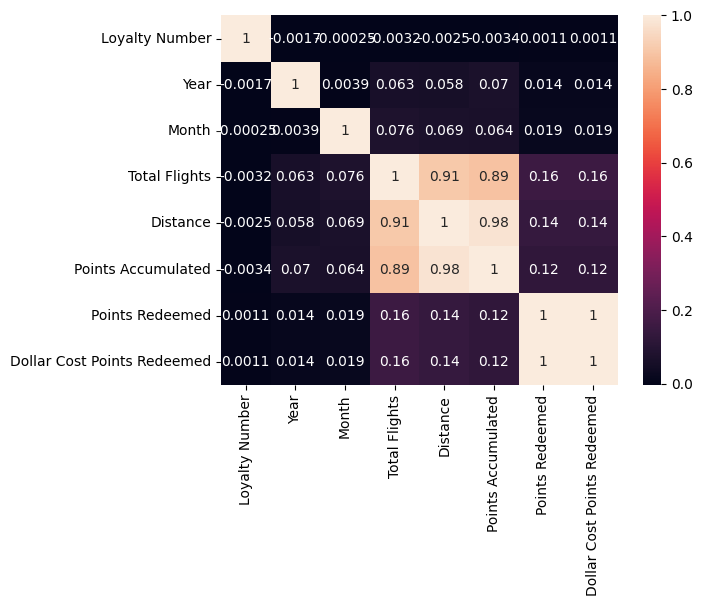

In [ ]:
sns.heatmap(activity.corr(),annot=True)

In [ ]:
activity = activity.drop(columns=['Dollar Cost Points Redeemed'])

### Feature Correlation Analysis and Multicollinearity Check

Examine correlations between numeric features in the activity data to identify potential multicollinearity issues and decide which features to retain for modeling.

<Axes: >

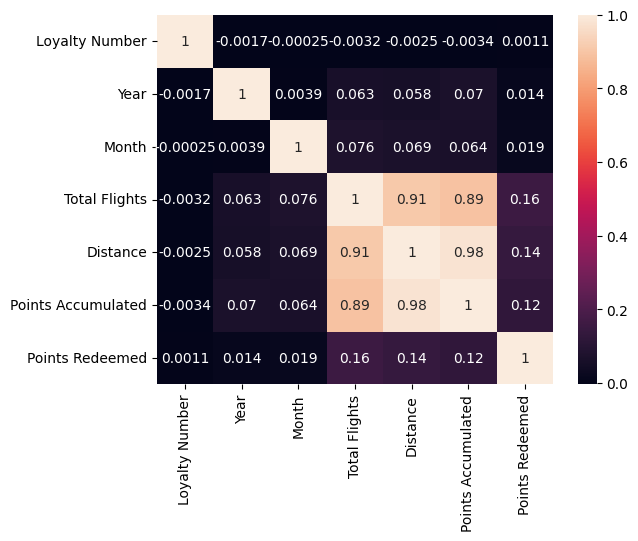

In [ ]:
sns.heatmap(activity.corr(),annot=True)

In [ ]:
activity_train = activity[activity['Year'] == 2017].copy()
activity_2018  = activity[activity['Year'] == 2018].copy()

### Split Activity Data by Year

Separate the aggregated activity data into 2017 (training/pre-churn period) and 2018 (post-churn period) cohorts to analyze customer behavior and churn patterns.

In [ ]:
activity_train.shape,activity_2018.shape

((189192, 7), (199873, 7))

In [ ]:
loyalty.head()

,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,NaN,NaN
1,549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,NaN,Divorced,Star,3839.61,Standard,2016,3,NaN,NaN
2,429460,Canada,British Columbia,Vancouver,V6E 3D9,Male,College,NaN,Single,Star,3839.75,Standard,2014,7,2018.0,1.0
3,608370,Canada,Ontario,Toronto,P1W 1K4,Male,College,NaN,Single,Star,3839.75,Standard,2013,2,NaN,NaN
4,530508,Canada,Quebec,Hull,J8Y 3Z5,Male,Bachelor,103495.0,Married,Star,3842.79,Standard,2014,10,NaN,NaN


## Loyalty Data Processing and Feature Engineering

This section processes the customer loyalty data by handling missing values, encoding categorical variables, and creating new features that will be used for churn prediction.

In [ ]:
loyalty.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16737 entries, 0 to 16736
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Loyalty Number      16737 non-null  int64  
 1   Country             16737 non-null  object 
 2   Province            16737 non-null  object 
 3   City                16737 non-null  object 
 4   Postal Code         16737 non-null  object 
 5   Gender              16737 non-null  object 
 6   Education           16737 non-null  object 
 7   Salary              12499 non-null  float64
 8   Marital Status      16737 non-null  object 
 9   Loyalty Card        16737 non-null  object 
 10  CLV                 16737 non-null  float64
 11  Enrollment Type     16737 non-null  object 
 12  Enrollment Year     16737 non-null  int64  
 13  Enrollment Month    16737 non-null  int64  
 14  Cancellation Year   2067 non-null   float64
 15  Cancellation Month  2067 non-null   float64
dtypes: f

### Initial Loyalty Data Inspection

Check the structure and identify any data quality issues (nulls, duplicates, invalid values) in the loyalty dataset.

In [ ]:
loyalty.duplicated().sum()

np.int64(0)

In [ ]:
loyalty.isnull().sum()

,0
Loyalty Number,0
Country,0
Province,0
City,0
Postal Code,0
Gender,0
Education,0
Salary,4238
Marital Status,0
Loyalty Card,0


In [ ]:
loyalty['Salary'].unique()

array([ 83236.,     nan, 103495., ...,  76178.,  91970., -57297.])

In [ ]:
print(f"\nNegative salaries: {(loyalty['Salary'] < 0).sum()}")


Negative salaries: 20


### Step 1: Fix Invalid Salary Values

The salary column contains errors: negative values (impossible—likely data entry mistakes) and missing values. We treat negative salaries as data errors and replace them with NaN for proper imputation.

In [ ]:
#  Fix negative salaries — treat as data errors, replace with NaN
loyalty.loc[loyalty['Salary'] < 0, 'Salary'] = np.nan

In [ ]:
print(f"\nNegative salaries: {(loyalty['Salary'] < 0).sum()}")


Negative salaries: 0


In [ ]:
#  Impute missing salary with median
salary_median = loyalty['Salary'].median()
loyalty['Salary_Was_Imputed'] = loyalty['Salary'].isna().astype(int)
loyalty['Salary'] = loyalty['Salary'].fillna(salary_median)
print(f"Salary nulls imputed: {loyalty['Salary_Was_Imputed'].sum()} with median {salary_median:.0f}")


Salary nulls imputed: 4258 with median 73510


### Step 2: Impute Missing Salaries

Create a boolean flag `Salary_Was_Imputed` to track which records had missing or invalid salaries, then impute missing salaries using the median value. This preserves information about data quality while ensuring no missing values for modeling.

In [ ]:
loyalty.isnull().sum()

,0
Loyalty Number,0
Country,0
Province,0
City,0
Postal Code,0
Gender,0
Education,0
Salary,0
Marital Status,0
Loyalty Card,0


In [ ]:
# Encode categoricals
loyalty['Male_Enc']       = (loyalty['Gender'] == 'Male').astype(int)
loyalty['Marital_Enc']    = loyalty['Marital Status'].map(
                            {'Single':0, 'Married':1, 'Divorced':2})
loyalty['Education_Enc']  = loyalty['Education'].map({
                            'High School or Below':0, 'College':1,
                            'Bachelor':2, 'Master':3, 'Doctor':4})
loyalty['Card_Enc']       = loyalty['Loyalty Card'].map(
                            {'Star':0, 'Nova':1, 'Aurora':2})
loyalty['Promo_Enroll']   = (loyalty['Enrollment Type'] == '2018 Promotion').astype(int)

### Step 3: Encode Categorical Variables

Convert categorical features into numeric encodings:
- **Gender**: Male (1) / Female (0)
- **Marital Status**: Single (0), Married (1), Divorced (2)
- **Education**: High School (0), College (1), Bachelor (2), Master (3), Doctor (4)
- **Loyalty Card**: Star (0), Nova (1), Aurora (2)
- **Enrollment Type**: 2018 Promotion (1), Other (0)

This enables the features to be used in machine learning models.

In [ ]:
loyalty.head()

,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,...,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month,Salary_Was_Imputed,Male_Enc,Marital_Enc,Education_Enc,Card_Enc,Promo_Enroll
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,...,2016,2,NaN,NaN,0,0,1,2,0,0
1,549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,73510.0,Divorced,Star,...,2016,3,NaN,NaN,1,1,2,1,0,0
2,429460,Canada,British Columbia,Vancouver,V6E 3D9,Male,College,73510.0,Single,Star,...,2014,7,2018.0,1.0,1,1,0,1,0,0
3,608370,Canada,Ontario,Toronto,P1W 1K4,Male,College,73510.0,Single,Star,...,2013,2,NaN,NaN,1,1,0,1,0,0
4,530508,Canada,Quebec,Hull,J8Y 3Z5,Male,Bachelor,103495.0,Married,Star,...,2014,10,NaN,NaN,0,1,1,2,0,0


In [ ]:
print(f"Salary imputed rows: {loyalty['Salary_Was_Imputed'].sum()}")

Salary imputed rows: 4258


In [ ]:
# Tenure at cutoff (end of 2017)
loyalty['Tenure_At_Cutoff'] = (
    (2017 - loyalty['Enrollment Year']) * 12 +
    (12   - loyalty['Enrollment Month'])
).clip(lower=0)

### Step 4: Drop Redundant Columns

Remove columns that are either too granular (city, postal code), have no variation (all Canadian customers), or have been replaced by encoded versions (gender, education, marital status, etc.). This improves model efficiency and reduces noise.

In [ ]:
# Drop raw columns that have been encoded or are not useful for modelling
cols_to_drop = [
    'Country',        # all Canadian customers, no variation
    'Province',       # too many categories, not useful for model
    'City',           # too many categories, not useful for model
    'Postal Code',    # too granular, not useful
    'Gender',         # replaced by Male_Enc
    'Education',      # replaced by Education_Enc
    'Marital Status', # replaced by Marital_Enc
    'Loyalty Card',   # replaced by Card_Enc
    'Enrollment Type' # replaced by Promo_Enroll
]

loyalty = loyalty.drop(columns=cols_to_drop)

print(loyalty.columns.tolist())
print(f"Shape after dropping: {loyalty.shape}")

['Loyalty Number', 'Salary', 'CLV', 'Enrollment Year', 'Enrollment Month', 'Cancellation Year', 'Cancellation Month', 'Salary_Was_Imputed', 'Male_Enc', 'Marital_Enc', 'Education_Enc', 'Card_Enc', 'Promo_Enroll', 'Tenure_At_Cutoff']
Shape after dropping: (16737, 14)


### Verify Data Quality After Cleanup

Confirm that all null values have been handled and that the dataset structure is ready for merging with activity data.

In [ ]:
loyalty.head()

,Loyalty Number,Salary,CLV,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month,Salary_Was_Imputed,Male_Enc,Marital_Enc,Education_Enc,Card_Enc,Promo_Enroll,Tenure_At_Cutoff
0,480934,83236.0,3839.14,2016,2,NaN,NaN,0,0,1,2,0,0,22
1,549612,73510.0,3839.61,2016,3,NaN,NaN,1,1,2,1,0,0,21
2,429460,73510.0,3839.75,2014,7,2018.0,1.0,1,1,0,1,0,0,41
3,608370,73510.0,3839.75,2013,2,NaN,NaN,1,1,0,1,0,0,58
4,530508,103495.0,3842.79,2014,10,NaN,NaN,0,1,1,2,0,0,38


<Axes: >

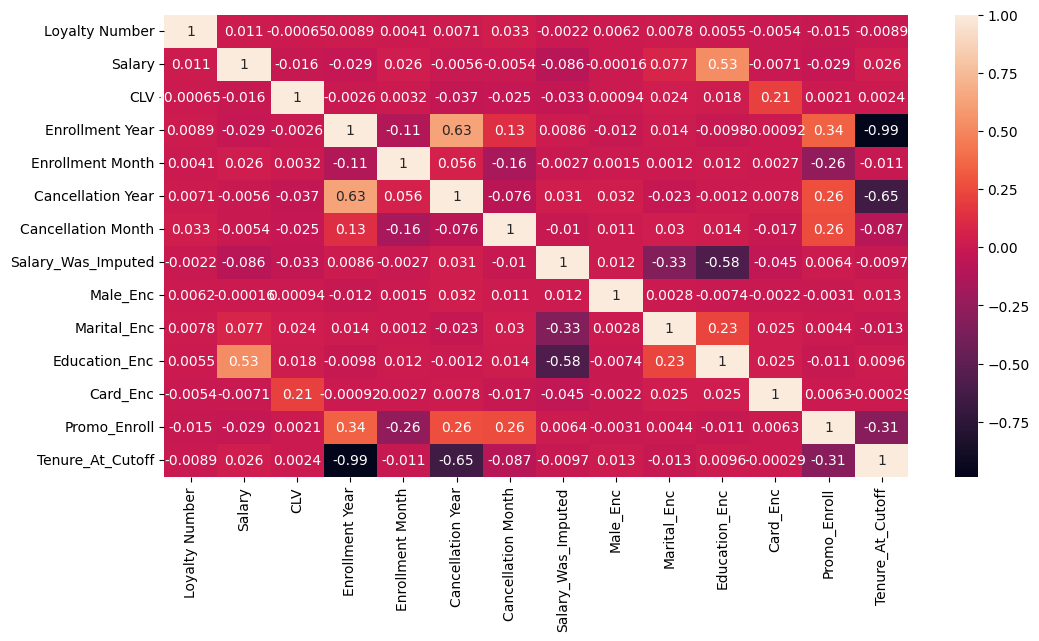

In [ ]:
plt.figure(figsize=(12,6))
sns.heatmap(loyalty.corr(),annot=True)

In [ ]:
loyalty = loyalty.drop(columns=['Enrollment Year', 'Enrollment Month'])

### Calculate Tenure at Cutoff

Compute the number of months each customer was enrolled at the end of 2017 (our cutoff point). Customers enrolled after 2017 will have zero tenure and will be excluded from modeling, as they lack pre-churn history.

In [ ]:
print(f"Unique customers in 2017: {activity_train['Loyalty Number'].nunique()}")
print(f"Unique customers in 2018: {activity_2018['Loyalty Number'].nunique()}")

Unique customers in 2017: 15766
Unique customers in 2018: 16737


In [ ]:
# Customers who formally cancelled in 2018
loyalty['Formal_Churn'] = (loyalty['Cancellation Year'] == 2018).astype(int)
# Customers who flew in 2018
flew_2018 = activity_2018.groupby('Loyalty Number')['Total Flights'].sum().reset_index()
flew_2018.columns = ['Loyalty Number', 'Flights_In_2018']

## Churn Labeling and Feature Engineering from Activity

Define churn using two complementary approaches and aggregate behavioral metrics from 2017 activity data.

In [ ]:
# Merge into loyalty
loyalty = loyalty.merge(flew_2018, on='Loyalty Number', how='left')
loyalty['Flights_In_2018'] = loyalty['Flights_In_2018'].fillna(0)

### Define Churn Labels

Create two churn definitions:
1. **Formal Churn**: Customers who formally cancelled their account in 2018
2. **Behavioral Churn**: Customers who were active in 2017 but made zero flights in 2018
3. **Combined Churn**: A customer is labeled as churned if either formal or behavioral churn occurred

This comprehensive approach captures both explicit and implicit churn signals.

In [ ]:
active_in_2017 = set(activity_train[activity_train['Total Flights'] > 0]['Loyalty Number'])
loyalty['Behavioral_Churn'] = (
    (loyalty['Loyalty Number'].isin(active_in_2017)) &
    (loyalty['Flights_In_2018'] == 0)
).astype(int)


In [ ]:
# Final churn label
loyalty['Churn'] = ((loyalty['Formal_Churn'] == 1) | (loyalty['Behavioral_Churn'] == 1)).astype(int)

print(f"Formal churn:     {loyalty['Formal_Churn'].sum()}")
print(f"Behavioral churn: {loyalty['Behavioral_Churn'].sum()}")
print(f"Total churn:      {loyalty['Churn'].sum()}")
print(f"Churn rate:       {loyalty['Churn'].mean()*100:.1f}%")

Formal churn:     645
Behavioral churn: 553
Total churn:      1163
Churn rate:       6.9%


In [ ]:
agg = activity_train.groupby('Loyalty Number').agg(
    Total_Flights      = ('Total Flights', 'sum'),
    Total_Distance     = ('Distance', 'sum'),
    Total_Points_Acc   = ('Points Accumulated', 'sum'),
    Total_Points_Red   = ('Points Redeemed', 'sum'),
    Active_Months      = ('Total Flights', lambda x: (x > 0).sum()),
    Max_Flights_Month  = ('Total Flights', 'max'),
    Total_Months       = ('Total Flights', 'count'),
).reset_index()

### Aggregate 2017 Activity Metrics

Create customer-level features from 2017 activity data:
- **Total Flights**: Sum of flights across all months
- **Total Distance**: Sum of miles flown
- **Total Points**: Accumulated and redeemed loyalty points
- **Active Months**: Number of months with at least one flight
- **Monthly Averages**: Normalized flight and distance metrics

These behavioral metrics serve as key predictors for churn.

In [ ]:
# Derived ratio features
agg['Avg_Flights_Month']       = agg['Total_Flights'] / agg['Total_Months'].clip(lower=1)
agg['Activity_Rate']           = agg['Active_Months'] / agg['Total_Months'].clip(lower=1)
agg['Redemption_Ratio']        = agg['Total_Points_Red'] / agg['Total_Points_Acc'].replace(0, np.nan)
agg['Redemption_Ratio']        = agg['Redemption_Ratio'].fillna(0)
agg['Avg_Distance_Per_Flight'] = agg['Total_Distance'] / agg['Total_Flights'].replace(0, np.nan)
agg['Avg_Distance_Per_Flight'] = agg['Avg_Distance_Per_Flight'].fillna(0)
print(f"Features built for {len(agg)} customers")
print(agg.head())


Features built for 15766 customers
   Loyalty Number  Total_Flights  Total_Distance  Total_Points_Acc  \
0          100018             24           37760           37760.0   
1          100102             25           39884           39884.0   
2          100140             22           31582           31582.0   
3          100214             10           18186           18186.0   
4          100272             20           28486           28486.0   

   Total_Points_Red  Active_Months  Max_Flights_Month  Total_Months  \
0              1128             10                  4            12   
1              1195              8                  5            12   
2                 0              9                  5            12   
3               861              4                  3            12   
4               393              6                  5            12   

   Avg_Flights_Month  Activity_Rate  Redemption_Ratio  Avg_Distance_Per_Flight  
0           2.000000       0.833333 

### Create Derived Ratio Features

Engineer additional features from aggregated metrics to capture customer engagement and activity patterns:
- **Activity Rate**: Proportion of active months (indicator of engagement consistency)
- **Redemption Ratio**: Loyalty points redeemed / points accumulated (indicator of program satisfaction)
- **Avg Distance Per Flight**: Total distance / total flights (indicator of trip type preference)
- **Recency**: Months since last flight in 2017 (indicator of current engagement)

These ratio-based features are more interpretable and robust to scale differences.

In [ ]:
# Months since last flight relative to Dec 2017
last_flight = activity_train[activity_train['Total Flights'] > 0].groupby('Loyalty Number')['Month'].max().reset_index()
last_flight.columns = ['Loyalty Number', 'Last_Active_Month']
last_flight['Months_Since_Last_Flight'] = 12 - last_flight['Last_Active_Month']

agg = agg.merge(last_flight[['Loyalty Number','Months_Since_Last_Flight']],
                on='Loyalty Number', how='left')

### Add Seasonal and Recency Features

Extract quarterly flight patterns from 2017 to capture seasonality in customer behavior. Recency (months since last flight) is a proven churn predictor in loyalty programs.

In [ ]:
agg['Months_Since_Last_Flight'] = agg['Months_Since_Last_Flight'].fillna(12)

print(agg['Months_Since_Last_Flight'].describe())

count    15766.000000
mean         3.204174
std          4.759978
min          0.000000
25%          0.000000
50%          1.000000
75%          4.000000
max         12.000000
Name: Months_Since_Last_Flight, dtype: float64


In [ ]:
# Flights per quarter in 2017
activity_train['Quarter'] = pd.cut(
    activity_train['Month'],
    bins=[0, 3, 6, 9, 12],
    labels=['Q1', 'Q2', 'Q3', 'Q4']
)

seasonal = activity_train.groupby(
    ['Loyalty Number', 'Quarter'])['Total Flights'].sum().unstack(fill_value=0)
seasonal.columns = [f'Flights_{c}' for c in seasonal.columns]
seasonal = seasonal.reset_index()

agg = agg.merge(seasonal, on='Loyalty Number', how='left')
agg[['Flights_Q1','Flights_Q2','Flights_Q3','Flights_Q4']] = \
    agg[['Flights_Q1','Flights_Q2','Flights_Q3','Flights_Q4']].fillna(0)

print(agg.head())

   Loyalty Number  Total_Flights  Total_Distance  Total_Points_Acc  \
0          100018             24           37760           37760.0   
1          100102             25           39884           39884.0   
2          100140             22           31582           31582.0   
3          100214             10           18186           18186.0   
4          100272             20           28486           28486.0   

   Total_Points_Red  Active_Months  Max_Flights_Month  Total_Months  \
0              1128             10                  4            12   
1              1195              8                  5            12   
2                 0              9                  5            12   
3               861              4                  3            12   
4               393              6                  5            12   

   Avg_Flights_Month  Activity_Rate  Redemption_Ratio  \
0           2.000000       0.833333          0.029873   
1           2.083333       0.666667   

/tmp/ipykernel_12111/773607222.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  seasonal = activity_train.groupby(


### Merge Datasets and Apply Filtering

Combine loyalty demographics with activity-derived behavioral features. Exclude customers enrolled after 2017 (insufficient history) and remove intermediate columns used only for label creation. The result is a clean, labeled dataset ready for modeling.

In [ ]:
model_df = loyalty.merge(agg, on='Loyalty Number', how='inner')

# Drop customers enrolled in 2018 ,they have zero pre-2018 history
model_df = model_df[model_df['Tenure_At_Cutoff'] > 0]

# Drop columns used only for label creation , NOT features
model_df = model_df.drop(columns=[
    'Cancellation Year', 'Cancellation Month',
    'Flights_In_2018', 'Formal_Churn', 'Behavioral_Churn'
])

print(f"Final dataset shape: {model_df.shape}")
print(f"Churn rate: {model_df['Churn'].mean()*100:.1f}%")


Final dataset shape: (13520, 27)
Churn rate: 7.0%


## Final Model Dataset Creation

Merge loyalty and activity features, apply filtering criteria, and create the final dataset ready for machine learning model development.

In [ ]:
model_df.to_csv('model_df.csv')